In [1]:
import torch
import torch.nn as nn
import numpy as np

In [3]:
import json

with open("../data/word2idx.json", "r") as f:
    word2idx = json.load(f)

vocab_size = len(word2idx)

print("Vocabulary loaded")
print("Vocab size:", vocab_size)

Vocabulary loaded
Vocab size: 20002


In [4]:
# Model configuration

vocab_size = len(word2idx)   
d_model = 128                
max_len = 100                

In [6]:
import numpy as np

X_train_ids = np.load("../data/X_train_ids.npy")
X_val_ids = np.load("../data/X_val_ids.npy")

y_train = np.load("../data/y_train.npy")
y_val = np.load("../data/y_val.npy")

print("Data loaded")
print("Train shape:", X_train_ids.shape)

Data loaded
Train shape: (108000, 100)


In [7]:
embedding_layer = nn.Embedding(
    num_embeddings=vocab_size,
    embedding_dim=d_model
)

# Example input
sample_input = torch.tensor([X_train_ids[0]])

embedded = embedding_layer(sample_input)

embedded.shape

/var/folders/pp/24nz6zh55d76389ml_1vblsc0000gn/T/ipykernel_44899/3793239029.py:7: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  sample_input = torch.tensor([X_train_ids[0]])


torch.Size([1, 100, 128])

In [8]:
def positional_encoding(max_len, d_model):

    pe = np.zeros((max_len, d_model))

    for pos in range(max_len):
        for i in range(0, d_model, 2):

            angle = pos / np.power(10000, (2 * i) / d_model)

            pe[pos, i] = np.sin(angle)

            if i + 1 < d_model:
                pe[pos, i + 1] = np.cos(angle)

    pe = torch.tensor(pe, dtype=torch.float32)

    return pe

In [9]:
pos_encoding = positional_encoding(max_len, d_model)

pos_encoding.shape

torch.Size([100, 128])

In [10]:
# Add position info to token embeddings

embedded_with_pos = embedded + pos_encoding.unsqueeze(0)

embedded_with_pos.shape

torch.Size([1, 100, 128])

In [11]:
class InputEmbedding(nn.Module):

    def __init__(self, vocab_size, d_model, max_len):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = positional_encoding(max_len, d_model)

    def forward(self, x):

        emb = self.embedding(x)

        # Move positional encoding to correct device
        pe = self.pos_encoding.to(x.device)

        emb = emb + pe.unsqueeze(0)

        return emb

In [12]:
input_embed = InputEmbedding(vocab_size, d_model, max_len)

test_output = input_embed(sample_input)

test_output.shape

torch.Size([1, 100, 128])

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [14]:
class ScaledDotProductAttention(nn.Module):

    def __init__(self):
        super().__init__()

    def forward(self, Q, K, V, mask=None):

        # Q,K,V shape:
        # (batch, heads, seq_len, d_k)

        d_k = Q.size(-1)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / torch.sqrt(
            torch.tensor(d_k, dtype=torch.float32)
        )

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attention_weights = F.softmax(scores, dim=-1)

        output = torch.matmul(attention_weights, V)

        return output, attention_weights

In [15]:
class MultiHeadAttention(nn.Module):

    def __init__(self, d_model, num_heads):
        super().__init__()

        assert d_model % num_heads == 0

        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        self.fc = nn.Linear(d_model, d_model)

        self.attention = ScaledDotProductAttention()

    def split_heads(self, x):

        batch_size, seq_len, d_model = x.size()

        x = x.view(
            batch_size,
            seq_len,
            self.num_heads,
            self.d_k
        )

        return x.permute(0, 2, 1, 3)

    def combine_heads(self, x):

        batch_size, heads, seq_len, d_k = x.size()

        x = x.permute(0, 2, 1, 3)

        return x.reshape(batch_size, seq_len, heads * d_k)

    def forward(self, x, mask=None):

        Q = self.split_heads(self.W_q(x))
        K = self.split_heads(self.W_k(x))
        V = self.split_heads(self.W_v(x))

        attn_output, attn_weights = self.attention(Q, K, V, mask)

        combined = self.combine_heads(attn_output)

        output = self.fc(combined)

        return output, attn_weights

In [16]:
num_heads = 4

mha = MultiHeadAttention(d_model, num_heads)

test_input = input_embed(sample_input)

output, weights = mha(test_input)

output.shape

torch.Size([1, 100, 128])

In [17]:
weights.shape

torch.Size([1, 4, 100, 100])

In [18]:
class PositionwiseFeedForward(nn.Module):

    def __init__(self, d_model, d_ff=512):
        super().__init__()

        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))

In [19]:
class EncoderLayer(nn.Module):

    def __init__(self, d_model, num_heads, d_ff=512, dropout=0.1):
        super().__init__()

        self.mha = MultiHeadAttention(d_model, num_heads)
        self.ffn = PositionwiseFeedForward(d_model, d_ff)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):

        # ---- Self-Attention ----
        attn_output, _ = self.mha(x, mask)
        x = self.norm1(x + self.dropout(attn_output))

        # ---- Feed-Forward ----
        ffn_output = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_output))

        return x

In [20]:
encoder_layer = EncoderLayer(d_model, num_heads)

test_input = input_embed(sample_input)

encoder_output = encoder_layer(test_input)

encoder_output.shape

torch.Size([1, 100, 128])

In [21]:
class TransformerEncoder(nn.Module):

    def __init__(self, vocab_size, d_model, num_heads,
                 num_layers, num_classes, max_len):

        super().__init__()

        # Input embedding
        self.embedding = InputEmbedding(vocab_size, d_model, max_len)

        # Stack of encoder layers
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads)
            for _ in range(num_layers)
        ])

        # Classification head
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x, mask=None):

        # Embedding + positional encoding
        x = self.embedding(x)

        # Pass through encoder layers
        for layer in self.layers:
            x = layer(x, mask)

        # ---- Pooling ----
        # Mean pooling across sequence dimension
        x = x.mean(dim=1)

        # Classification
        logits = self.classifier(x)

        return logits

In [22]:
num_heads = 4
num_layers = 2
num_classes = 4  # AG News categories

In [23]:
model = TransformerEncoder(
    vocab_size=vocab_size,
    d_model=d_model,
    num_heads=num_heads,
    num_layers=num_layers,
    num_classes=num_classes,
    max_len=max_len
)

model

TransformerEncoder(
  (embedding): InputEmbedding(
    (embedding): Embedding(20002, 128)
  )
  (layers): ModuleList(
    (0-1): 2 x EncoderLayer(
      (mha): MultiHeadAttention(
        (W_q): Linear(in_features=128, out_features=128, bias=True)
        (W_k): Linear(in_features=128, out_features=128, bias=True)
        (W_v): Linear(in_features=128, out_features=128, bias=True)
        (fc): Linear(in_features=128, out_features=128, bias=True)
        (attention): ScaledDotProductAttention()
      )
      (ffn): PositionwiseFeedForward(
        (fc1): Linear(in_features=128, out_features=512, bias=True)
        (fc2): Linear(in_features=512, out_features=128, bias=True)
      )
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (classifier): Linear(in_features=128, out_features=4, bias=True)
)

In [24]:
sample_batch = torch.tensor(X_train_ids[:4])

output = model(sample_batch)

output.shape

torch.Size([4, 4])

In [25]:
probs = torch.softmax(output, dim=-1)

probs

tensor([[0.2529, 0.2612, 0.1804, 0.3054],
        [0.2591, 0.2644, 0.1768, 0.2997],
        [0.2598, 0.2842, 0.1731, 0.2829],
        [0.2763, 0.2601, 0.1809, 0.2827]], grad_fn=<SoftmaxBackward0>)

In [26]:
# Convert datasets to PyTorch tensors

X_train_tensor = torch.tensor(X_train_ids, dtype=torch.long)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val_ids, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

print("Training tensor shape:", X_train_tensor.shape)

Training tensor shape: torch.Size([108000, 100])


In [27]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 64

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size
)

In [28]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [29]:
def train_one_epoch(model, loader, optimizer, criterion):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in loader:

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)

        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    accuracy = correct / total

    return total_loss / len(loader), accuracy

In [30]:
def evaluate(model, loader, criterion):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, y_batch in loader:

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            total_loss += loss.item()

            preds = outputs.argmax(dim=1)

            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    accuracy = correct / total

    return total_loss / len(loader), accuracy

In [31]:
epochs = 5

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(epochs):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1}: "
        f"Train Loss={train_loss:.4f}, "
        f"Train Acc={train_acc:.4f}, "
        f"Val Loss={val_loss:.4f}, "
        f"Val Acc={val_acc:.4f}"
    )

Epoch 1: Train Loss=0.4641, Train Acc=0.8284, Val Loss=0.3144, Val Acc=0.8928
Epoch 2: Train Loss=0.2825, Train Acc=0.9040, Val Loss=0.3048, Val Acc=0.8967
Epoch 3: Train Loss=0.2317, Train Acc=0.9212, Val Loss=0.2836, Val Acc=0.9069
Epoch 4: Train Loss=0.1999, Train Acc=0.9322, Val Loss=0.2738, Val Acc=0.9117
Epoch 5: Train Loss=0.1740, Train Acc=0.9404, Val Loss=0.2694, Val Acc=0.9127


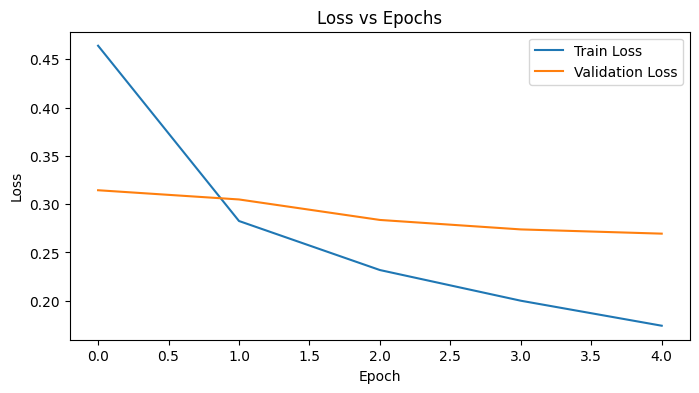

In [32]:
import matplotlib.pyplot as plt

# Loss curves
plt.figure(figsize=(8,4))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

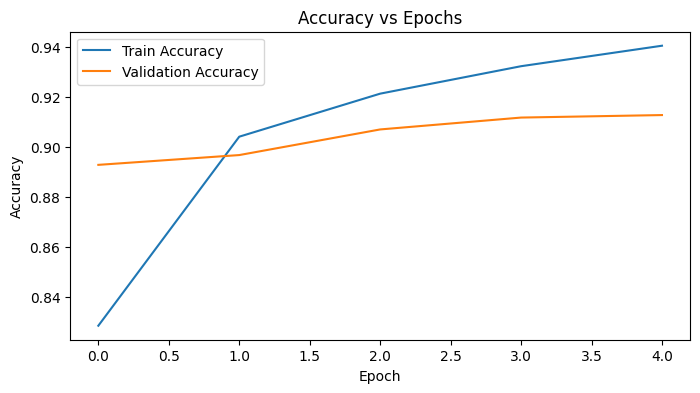

In [33]:
plt.figure(figsize=(8,4))

plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")

plt.title("Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [34]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for X_batch, y_batch in val_loader:

        outputs = model(X_batch)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.tolist())
        all_labels.extend(y_batch.tolist())

In [36]:
# AG News label names

label_names = [
    "World",
    "Sports",
    "Business",
    "Sci/Tech"
]

print("Labels loaded:", label_names)

Labels loaded: ['World', 'Sports', 'Business', 'Sci/Tech']


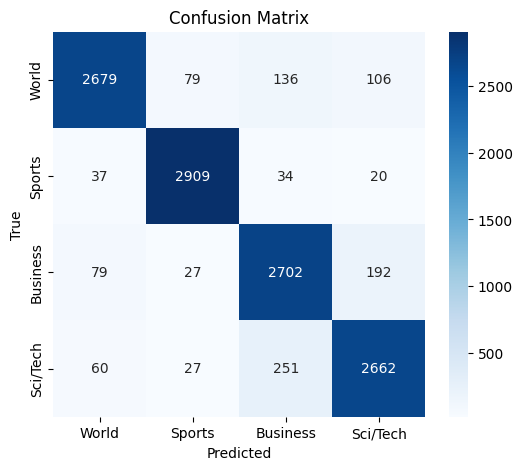

In [37]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [38]:
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_preds,
    target_names=label_names
))

              precision    recall  f1-score   support

       World       0.94      0.89      0.92      3000
      Sports       0.96      0.97      0.96      3000
    Business       0.87      0.90      0.88      3000
    Sci/Tech       0.89      0.89      0.89      3000

    accuracy                           0.91     12000
   macro avg       0.91      0.91      0.91     12000
weighted avg       0.91      0.91      0.91     12000



In [40]:
import json

with open("../data/X_val_text.json", "r") as f:
    X_val = json.load(f)

print("Validation texts loaded:", len(X_val))

Validation texts loaded: 12000


In [41]:
# Show some validation samples with predictions

for i in range(5):

    text = X_val[i][:200]  # truncated text for display

    print("True label:", label_names[y_val[i]])
    print("Predicted:", label_names[all_preds[i]])
    print("-" * 50)

True label: Sci/Tech
Predicted: Sci/Tech
--------------------------------------------------
True label: Sci/Tech
Predicted: Sports
--------------------------------------------------
True label: World
Predicted: World
--------------------------------------------------
True label: Business
Predicted: Business
--------------------------------------------------
True label: Business
Predicted: Sports
--------------------------------------------------


In [42]:
import json

with open("../data/X_val_text.json", "r") as f:
    X_val = json.load(f)

print("Validation texts loaded:", len(X_val))

Validation texts loaded: 12000


In [43]:
label_names = [
    "World",
    "Sports",
    "Business",
    "Sci/Tech"
]

In [44]:
print("✅ Correct Predictions\n")

count = 0

for i in range(len(all_preds)):
    if all_preds[i] == y_val[i]:

        print("TEXT:", X_val[i][:200])
        print("TRUE:", label_names[y_val[i]])
        print("PRED:", label_names[all_preds[i]])
        print("-" * 60)

        count += 1
        if count == 3:
            break

✅ Correct Predictions

TEXT: Orange Unveils 3G Phones in Long-Delayed Launch  LONDON/PARIS (Reuters) - Orange unveiled its  third-generation (3G) mobile phones in a long-delayed  commercial launch, with seven new handset models a
TRUE: Sci/Tech
PRED: Sci/Tech
------------------------------------------------------------
TEXT: Charity director kidnapped in Iraq Insurgents abducted the local director of CARE International from her car in Baghdad yesterday, targeting a charity worker who has championed ordinary Iraqis for dec
TRUE: World
PRED: World
------------------------------------------------------------
TEXT: Canadian Bonds Gain; Rising Oil Prices May Curb Economic Growth Canadian bonds gained on concern that the North American economy may slow as higher prices of oil translate into greater transportation 
TRUE: Business
PRED: Business
------------------------------------------------------------


In [45]:
print("❌ Incorrect Predictions\n")

count = 0

for i in range(len(all_preds)):
    if all_preds[i] != y_val[i]:

        print("TEXT:", X_val[i][:200])
        print("TRUE:", label_names[y_val[i]])
        print("PRED:", label_names[all_preds[i]])
        print("-" * 60)

        count += 1
        if count == 3:
            break

❌ Incorrect Predictions

TEXT: Rival Technologies Vie for 'Green' Car of Tomorrow  PARIS (Reuters) - Carmakers presented new-age automobiles  at the Paris car show on Thursday that could give much-hyped  fuel cells a run for their 
TRUE: Sci/Tech
PRED: Sports
------------------------------------------------------------
TEXT: Were You Ready for Some Football? Disney kicks off another season of Monday Night Football -- on a Thursday.
TRUE: Business
PRED: Sports
------------------------------------------------------------
TEXT: Better bet the Boss will be rebuilding his empire  quot;What a Choke, #39; #39;  quot;Hell Freezes Over, #39; #39;  quot;Damned Yankees, #39; #39; and  quot;Monumental Collapse #39; #39; were found on
TRUE: Sports
PRED: World
------------------------------------------------------------


In [46]:
def get_attention_weights(model, input_ids):

    model.eval()

    with torch.no_grad():

        x = model.embedding(input_ids)

        # Get attention from first layer
        layer = model.layers[0]
        attn_output, attn_weights = layer.mha(x)

    return attn_weights

In [47]:
sample_ids = torch.tensor([X_val_ids[0]])

attn_weights = get_attention_weights(model, sample_ids)

attn_weights.shape

torch.Size([1, 4, 100, 100])

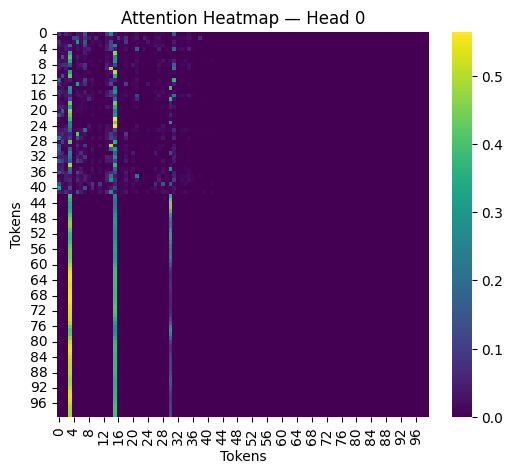

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

head = 0

matrix = attn_weights[0, head].numpy()

plt.figure(figsize=(6,5))

sns.heatmap(matrix, cmap="viridis")

plt.title(f"Attention Heatmap — Head {head}")
plt.xlabel("Tokens")
plt.ylabel("Tokens")

plt.show()

In [50]:
import os
import torch

# Ensure models directory exists
os.makedirs("../models", exist_ok=True)

# Save model weights
torch.save(model.state_dict(), "../models/transformer_encoder.pt")

print("Model saved successfully")

Model saved successfully


In [51]:
torch.save({
    "model_state_dict": model.state_dict(),
    "train_losses": train_losses,
    "val_losses": val_losses,
    "train_accs": train_accs,
    "val_accs": val_accs
}, "../models/transformer_checkpoint.pt")